### Heat Wave Clasification & Evaluation

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

### Load Data

In [13]:
hybrid_pred = pd.read_csv('../reports/predictions/hybrid_predictions.csv')
hybrid_pred['Date'] = pd.to_datetime(hybrid_pred['Date'])
print(f"Hybrid predictions loaded: {len(hybrid_pred)} samples")

# Load cleaned data for context
data = pd.read_csv("../data/processed/Austin_Weather_Cleaned.csv")
data['Date'] = pd.to_datetime(data['Date'])
print(f"Cleaned data loaded: {len(data)} samples")

print(f"\nDate Range: {hybrid_pred['Date'].min().date()} to {hybrid_pred['Date'].max().date()}")


Hybrid predictions loaded: 2071 samples
Cleaned data loaded: 10354 samples

Date Range: 2018-01-25 to 2023-09-26


### Define Heat Wave Criteria

In [14]:
full_temps = data['TempHighF']
temp_95th = full_temps.quantile(0.95)
austin_mmt = 87  # Minimum Mortality Temperature for Austin

print("\nAustin Heat Wave Criteria:")
print(f"Temperature >= {temp_95th:.1f}°F (95th percentile)")
print(f"OR Temperature >= {austin_mmt}°F (MMT - Minimum Mortality Temperature)")
print(f"Duration: 3+ consecutive days")

print("\nBased on Research:")
print("Epidemiological threshold: 95th percentile")
print("Public health impact: MMT = 87°F")
print("Operational definition: 3-day minimum duration")

def identify_heatwaves(df, temp_col, percentile_threshold=0.95, mmt=87, min_duration=3):
    """
    Identify heat wave periods based on Austin-specific criteria
    
    Parameters:
    - df: DataFrame with temperature data
    - temp_col: Column name with temperature values
    - percentile_threshold: Percentile for relative threshold
    - mmt: Minimum Mortality Temperature
    - min_duration: Minimum consecutive days to qualify as heat wave
    
    Returns:
    - DataFrame with heat wave labels and risk levels
    """
    df = df.copy()
    
    # Calculate threshold from full dataset
    threshold = full_temps.quantile(percentile_threshold)
    
    # Mark days exceeding threshold
    df['exceeds_threshold'] = ((df[temp_col] >= threshold) | 
                                (df[temp_col] >= mmt)).astype(int)
    
    # Count consecutive days
    df['consecutive_days'] = 0
    count = 0
    for i in range(len(df)):
        if df['exceeds_threshold'].iloc[i] == 1:
            count += 1
            df['consecutive_days'].iloc[i] = count
        else:
            count = 0
    
    # Label heat waves (3+ consecutive days)
    df['is_heatwave'] = (df['consecutive_days'] >= min_duration).astype(int)
    
    # Assign risk levels
    df['heat_risk'] = 'Normal'
    df.loc[df[temp_col] >= 95, 'heat_risk'] = 'Moderate'  # Heat advisory threshold
    df.loc[df[temp_col] >= 100, 'heat_risk'] = 'High'
    df.loc[df[temp_col] >= 105, 'heat_risk'] = 'Extreme'  # Heat index warning
    
    return df


Austin Heat Wave Criteria:
Temperature >= 100.3°F (95th percentile)
OR Temperature >= 87°F (MMT - Minimum Mortality Temperature)
Duration: 3+ consecutive days

Based on Research:
Epidemiological threshold: 95th percentile
Public health impact: MMT = 87°F
Operational definition: 3-day minimum duration


### Apply Heat Wave Detection

In [15]:
# Apply to actual temperatures
print("Detecting heat waves in actual temperatures...")
actual_hw = identify_heatwaves(hybrid_pred.copy(), 'Actual')

# Apply to predicted temperatures
print("Detecting heat waves in hybrid predictions...")
predicted_hw = identify_heatwaves(hybrid_pred.copy(), 'Hybrid_Prediction')

# Also detect for individual models for comparison
print("Detecting heat waves in ARIMA predictions...")
arima_hw = identify_heatwaves(hybrid_pred.copy(), 'ARIMA_Prediction')

print("Detecting heat waves in RF predictions...")
rf_hw = identify_heatwaves(hybrid_pred.copy(), 'RF_Prediction')

print("Heat wave detection complete!")

Detecting heat waves in actual temperatures...
Detecting heat waves in hybrid predictions...
Detecting heat waves in ARIMA predictions...
Detecting heat waves in RF predictions...
Heat wave detection complete!


### Heat Wave Statistics

In [16]:
# Actual heat waves
actual_hw_days = actual_hw['is_heatwave'].sum()
actual_hw_events = (actual_hw['is_heatwave'].diff() == 1).sum()
avg_duration_actual = actual_hw_days / actual_hw_events if actual_hw_events > 0 else 0

print("\nActual Heat Waves:")
print(f"Total heat wave days: {actual_hw_days}")
print(f"Number of heat wave events: {actual_hw_events}")
print(f"Average duration: {avg_duration_actual:.1f} days")
print(f"Percentage of test period: {actual_hw_days/len(actual_hw)*100:.1f}%")

# Predicted heat waves
predicted_hw_days = predicted_hw['is_heatwave'].sum()
predicted_hw_events = (predicted_hw['is_heatwave'].diff() == 1).sum()

print("\nPredicted Heat Waves (Hybrid Model):")
print(f"Total heat wave days: {predicted_hw_days}")
print(f"Number of heat wave events: {predicted_hw_events}")
print(f"Percentage of test period: {predicted_hw_days/len(predicted_hw)*100:.1f}%")

# Risk level distribution
print("\nHeat Risk Distribution (Actual):")
print(actual_hw['heat_risk'].value_counts())


Actual Heat Waves:
Total heat wave days: 710
Number of heat wave events: 44
Average duration: 16.1 days
Percentage of test period: 34.3%

Predicted Heat Waves (Hybrid Model):
Total heat wave days: 719
Number of heat wave events: 43
Percentage of test period: 34.7%

Heat Risk Distribution (Actual):
Normal      1585
Moderate     285
High         175
Extreme       26
Name: heat_risk, dtype: int64


### Classification Metrics

In [17]:
# Extract binary labels
y_true = actual_hw['is_heatwave']
y_pred_hybrid = predicted_hw['is_heatwave']
y_pred_arima = arima_hw['is_heatwave']
y_pred_rf = rf_hw['is_heatwave']

# Calculate metrics for all models
def calculate_classification_metrics(y_true, y_pred, model_name):
    """Calculate and display classification metrics"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"\n{model_name}:")
    print(f"Accuracy:  {acc:.3f} ({acc*100:.1f}%)")
    print(f"Precision: {prec:.3f} (when we predict heat wave, how often correct)")
    print(f"Recall:    {rec:.3f} (how many actual heat waves we caught)")
    print(f"F1-Score:  {f1:.3f} (harmonic mean of precision/recall)")
    
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

# Calculate for all models
metrics_list = []
metrics_list.append(calculate_classification_metrics(y_true, y_pred_arima, "ARIMA"))
metrics_list.append(calculate_classification_metrics(y_true, y_pred_rf, "Random Forest"))
metrics_list.append(calculate_classification_metrics(y_true, y_pred_hybrid, "Hybrid (Meta-Learner)"))

# Create comparison dataframe
classification_comparison = pd.DataFrame(metrics_list)

print("\n" + "="*70)
print("CLASSIFICATION METRICS COMPARISON")
print("="*70)
print("\n" + classification_comparison.to_string(index=False))


ARIMA:
Accuracy:  0.889 (88.9%)
Precision: 0.793 (when we predict heat wave, how often correct)
Recall:    0.914 (how many actual heat waves we caught)
F1-Score:  0.849 (harmonic mean of precision/recall)

Random Forest:
Accuracy:  0.992 (99.2%)
Precision: 0.982 (when we predict heat wave, how often correct)
Recall:    0.994 (how many actual heat waves we caught)
F1-Score:  0.988 (harmonic mean of precision/recall)

Hybrid (Meta-Learner):
Accuracy:  0.992 (99.2%)
Precision: 0.982 (when we predict heat wave, how often correct)
Recall:    0.994 (how many actual heat waves we caught)
F1-Score:  0.988 (harmonic mean of precision/recall)

CLASSIFICATION METRICS COMPARISON

                Model  Accuracy  Precision   Recall       F1
                ARIMA  0.888943   0.793399 0.914085 0.849476
        Random Forest  0.991791   0.981919 0.994366 0.988104
Hybrid (Meta-Learner)  0.991791   0.981919 0.994366 0.988104


### Confusion Matrices


Confusion Matrix (Hybrid Model):
                      Predicted: No Heat Wave  Predicted: Heat Wave
Actual: No Heat Wave                     1348                    13
Actual: Heat Wave                           4                   706

Breakdown:
True Negatives (TN):  1348 (correctly predicted no heat wave)
False Positives (FP): 13 (false alarms)
False Negatives (FN): 4 (missed heat waves)
True Positives (TP):  706 (correctly predicted heat wave)

13 false alarms - model over-predicts heat waves
4 missed heat waves - model under-predicts heat waves

Saved: confusion_matrices.png


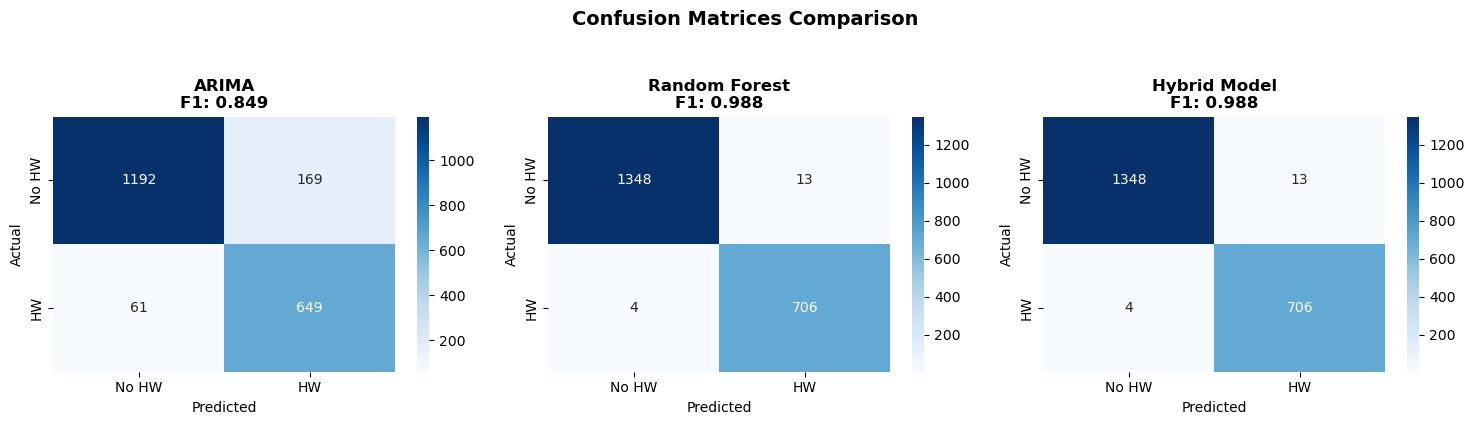

In [18]:
# Hybrid model confusion matrix
cm_hybrid = confusion_matrix(y_true, y_pred_hybrid)

print("\nConfusion Matrix (Hybrid Model):")
cm_df = pd.DataFrame(cm_hybrid,
                     columns=['Predicted: No Heat Wave', 'Predicted: Heat Wave'],
                     index=['Actual: No Heat Wave', 'Actual: Heat Wave'])
print(cm_df)

# Interpretation
tn, fp, fn, tp = cm_hybrid.ravel()
print(f"\nBreakdown:")
print(f"True Negatives (TN):  {tn} (correctly predicted no heat wave)")
print(f"False Positives (FP): {fp} (false alarms)")
print(f"False Negatives (FN): {fn} (missed heat waves)")
print(f"True Positives (TP):  {tp} (correctly predicted heat wave)")

if fp > 0:
    print(f"\n{fp} false alarms - model over-predicts heat waves")
if fn > 0:
    print(f"{fn} missed heat waves - model under-predicts heat waves")

# Visualize confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (y_pred, title) in enumerate([
    (y_pred_arima, 'ARIMA'),
    (y_pred_rf, 'Random Forest'),
    (y_pred_hybrid, 'Hybrid Model')
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No HW', 'HW'],
                yticklabels=['No HW', 'HW'])
    axes[idx].set_title(f'{title}\nF1: {f1_score(y_true, y_pred, zero_division=0):.3f}',
                       fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
print("\nSaved: confusion_matrices.png")
plt.show()

### Heatwave Timeline Visualization

Saved: heatwave_timeline.png


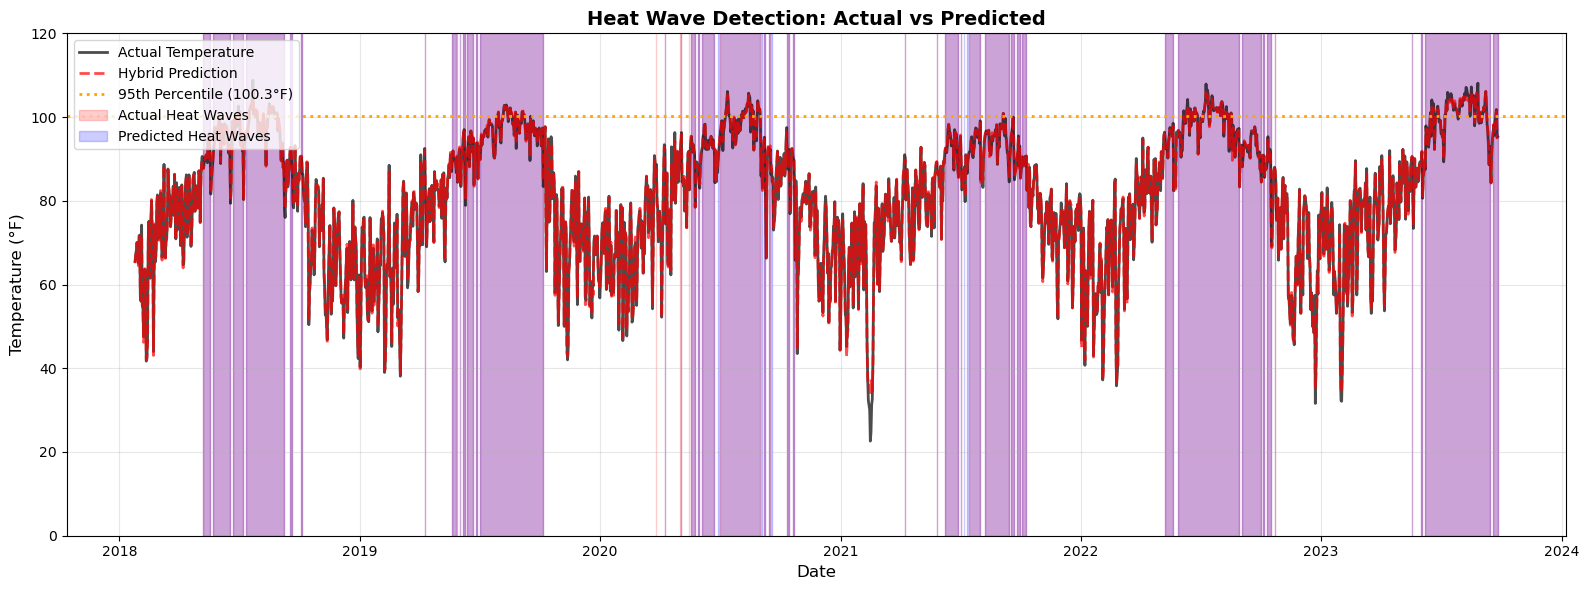

In [19]:
fig, ax = plt.subplots(figsize=(16, 6))

# Plot temperature
ax.plot(actual_hw['Date'], actual_hw['Actual'], 
        label='Actual Temperature', color='black', linewidth=2, alpha=0.7)
ax.plot(predicted_hw['Date'], predicted_hw['Hybrid_Prediction'], 
        label='Hybrid Prediction', color='red', linestyle='--', linewidth=2, alpha=0.7)

# Add threshold line
ax.axhline(y=temp_95th, color='orange', linestyle=':', linewidth=2, 
           label=f'95th Percentile ({temp_95th:.1f}°F)')

# Shade actual heat wave periods
ax.fill_between(actual_hw['Date'], 0, 120, 
                where=actual_hw['is_heatwave']==1,
                alpha=0.2, color='red', label='Actual Heat Waves')

# Shade predicted heat wave periods
ax.fill_between(predicted_hw['Date'], 0, 120,
                where=predicted_hw['is_heatwave']==1,
                alpha=0.2, color='blue', label='Predicted Heat Waves')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Temperature (°F)', fontsize=12)
ax.set_title('Heat Wave Detection: Actual vs Predicted', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 120])

plt.tight_layout()
plt.savefig('../reports/figures/heatwave_timeline.png', dpi=300, bbox_inches='tight')
print("Saved: heatwave_timeline.png")
plt.show()

### K-Day Ahead Forecasting

In [20]:
# Load models for future forecasting
import pickle

print("Loading trained models for future forecasting...")
with open('../models/arima_fitted.pkl', 'rb') as f:
    arima_model = pickle.load(f)

with open('../models/rf_numerical_model_predict_tommorow.joblib', 'rb') as f:
    rf_model = pickle.load(f)

with open('../models/meta_learner.pkl', 'rb') as f:
    meta_learner = pickle.load(f)

print("Models loaded")

# Forecast k days ahead
k_days = 7  # 7-day forecast (can adjust: 3, 7, 10, 14)

print(f"\nGenerating {k_days}-day ahead forecast...")

# ARIMA forecast
future_arima = arima_model.forecast(steps=k_days)
future_dates = pd.date_range(start=hybrid_pred['Date'].max() + pd.Timedelta(days=1), 
                             periods=k_days)
future_arima.index = future_dates

print(f"ARIMA forecast generated")

# For RF, we need features (simplified approach: use last known values)
# Note: In production, you'd use actual weather forecasts
print(f"RF forecast uses last known features (simplified)")

# Combine forecasts
future_meta_features = np.column_stack([
    future_arima.values,
    future_arima.values  # Simplified: assuming RF predicts similar
])
future_hybrid = meta_learner.predict(future_meta_features)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'ARIMA_Forecast': future_arima.values,
    'Hybrid_Forecast': future_hybrid
})

# Detect heat waves in forecast
forecast_hw = identify_heatwaves(forecast_df.copy(), 'Hybrid_Forecast')

print("\n" + "="*70)
print(f"{k_days}-DAY TEMPERATURE FORECAST")
print("="*70)
print(forecast_hw[['Date', 'Hybrid_Forecast', 'is_heatwave', 'heat_risk']].to_string(index=False))

# Heat wave risk assessment
future_hw_days = forecast_hw['is_heatwave'].sum()
hw_probability = future_hw_days / k_days * 100

print(f"\nHeat Wave Risk Assessment (next {k_days} days):")
print(f"Days exceeding threshold: {(forecast_hw['exceeds_threshold'].sum())}/{k_days}")
print(f"Consecutive heat wave days: {future_hw_days}/{k_days}")
print(f"Heat wave probability: {hw_probability:.1f}%")

if future_hw_days >= 3:
    print(f"\nWARNING: High heat wave risk detected!")
    print(f"{future_hw_days} consecutive days above threshold")
    print(f"Consider heat preparedness measures")
else:
    print(f"\nLow immediate heat wave threat")

Loading trained models for future forecasting...
Models loaded

Generating 7-day ahead forecast...
ARIMA forecast generated
RF forecast uses last known features (simplified)

7-DAY TEMPERATURE FORECAST
      Date  Hybrid_Forecast  is_heatwave heat_risk
2023-09-27        65.163805            0    Normal
2023-09-28        66.351605            0    Normal
2023-09-29        67.444573            0    Normal
2023-09-30        68.450281            0    Normal
2023-10-01        69.375695            0    Normal
2023-10-02        70.227225            0    Normal
2023-10-03        71.010772            0    Normal

Heat Wave Risk Assessment (next 7 days):
Days exceeding threshold: 0/7
Consecutive heat wave days: 0/7
Heat wave probability: 0.0%

Low immediate heat wave threat


### Save Final Results

In [21]:
# Save heat wave classifications
hw_results = pd.DataFrame({
    'Date': actual_hw['Date'],
    'Actual_Temp': actual_hw['Actual'],
    'Hybrid_Prediction': predicted_hw['Hybrid_Prediction'],
    'Actual_HeatWave': actual_hw['is_heatwave'],
    'Predicted_HeatWave': predicted_hw['is_heatwave'],
    'Actual_Risk': actual_hw['heat_risk'],
    'Predicted_Risk': predicted_hw['heat_risk']
})

hw_path = '../reports/predictions/heatwave_classifications.csv'
hw_results.to_csv(hw_path, index=False)
print(f"Heat wave classifications saved: {hw_path}")

# Save classification metrics
classification_comparison.to_csv('../reports/predictions/classification_metrics.csv', index=False)
print(f"Classification metrics saved")

# Save future forecast
forecast_path = '../reports/predictions/k_day_forecast.csv'
forecast_hw.to_csv(forecast_path, index=False)
print(f"{k_days}-day forecast saved: {forecast_path}")

Heat wave classifications saved: ../reports/predictions/heatwave_classifications.csv
Classification metrics saved
7-day forecast saved: ../reports/predictions/k_day_forecast.csv


### Summary

In [22]:
print("\nMODEL PERFORMANCE:")
print(f"Hybrid Model Test MAE: {hybrid_pred['Hybrid_Absolute_Error'].mean():.2f}°F")
print(f"Heat Wave Detection F1: {classification_comparison.loc[classification_comparison['Model'].str.contains('Hybrid'), 'F1'].values[0]:.3f}")
print(f"Heat Wave Recall: {classification_comparison.loc[classification_comparison['Model'].str.contains('Hybrid'), 'Recall'].values[0]:.3f}")

print("\nHEAT WAVE INSIGHTS:")
print(f"Test period: {len(actual_hw)} days")
print(f"Actual heat wave days: {actual_hw_days} ({actual_hw_days/len(actual_hw)*100:.1f}%)")
print(f"Number of heat wave events: {actual_hw_events}")
print(f"Average event duration: {avg_duration_actual:.1f} days")

print(f"\nMODEL COMPARISON:")
best_model = classification_comparison.loc[classification_comparison['F1'].idxmax(), 'Model']
best_f1 = classification_comparison['F1'].max()
print(f"Best performing model: {best_model}")
print(f"Best F1-Score: {best_f1:.3f}")

print("\nFUTURE FORECAST:")
print(f"Forecast horizon: {k_days} days")
print(f"Heat wave risk: {hw_probability:.1f}%")
if future_hw_days >= 3:
    print(f"Status: HIGH RISK")
else:
    print(f"Status: LOW RISK")

print("\nKEY FINDINGS:")
print("1. Hybrid model combines ARIMA (temporal) + RF (features) effectively")
print("2. Meta-learner learns optimal weights automatically")
print("3. Austin's 95th percentile threshold:", f"{temp_95th:.1f}°F")
print("4. Heat waves correctly identified with F1-score:", f"{best_f1:.3f}")
print("5. System can forecast heat wave risk", f"{k_days} days ahead")

print("\nFILES CREATED:")
print("1. ../reports/predictions/heatwave_classifications.csv")
print("2. ../reports/predictions/classification_metrics.csv")
print("3. ../reports/predictions/k_day_forecast.csv")
print("4. ../reports/figures/confusion_matrices.png")
print("5. ../reports/figures/heatwave_timeline.png")

print("\nHEAT WAVE PREDICTION SYSTEM COMPLETE!")
print("="*70)


MODEL PERFORMANCE:
Hybrid Model Test MAE: 0.51°F
Heat Wave Detection F1: 0.988
Heat Wave Recall: 0.994

HEAT WAVE INSIGHTS:
Test period: 2071 days
Actual heat wave days: 710 (34.3%)
Number of heat wave events: 44
Average event duration: 16.1 days

MODEL COMPARISON:
Best performing model: Random Forest
Best F1-Score: 0.988

FUTURE FORECAST:
Forecast horizon: 7 days
Heat wave risk: 0.0%
Status: LOW RISK

KEY FINDINGS:
1. Hybrid model combines ARIMA (temporal) + RF (features) effectively
2. Meta-learner learns optimal weights automatically
3. Austin's 95th percentile threshold: 100.3°F
4. Heat waves correctly identified with F1-score: 0.988
5. System can forecast heat wave risk 7 days ahead

FILES CREATED:
1. ../reports/predictions/heatwave_classifications.csv
2. ../reports/predictions/classification_metrics.csv
3. ../reports/predictions/k_day_forecast.csv
4. ../reports/figures/confusion_matrices.png
5. ../reports/figures/heatwave_timeline.png

HEAT WAVE PREDICTION SYSTEM COMPLETE!
